## **Verificar GPU**

In [ ]:
!nvidia-smi
import torch
print(f"CUDA: {torch.cuda.is_available()}")

Mon May 11 00:54:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## **Instalar YOLO**

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.1 MB/s eta 0:00:00


## **Montar Drive e descompactar**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# Ajuste o caminho do seu zip
ZIP_PATH = "/content/drive/MyDrive/TreinamentoManual-YOLO2.0.zip"

print("Descompactando...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Conteúdo:")
print(os.listdir("/content/dataset"))

Mounted at /content/drive
Descompactando...
Conteúdo:
['classes.txt', 'labels', 'images', 'notes.json']


## **Ver estrutura e criar YAML**

In [ ]:
import os

# Mostra a estrutura extraída
for root, dirs, files in os.walk("/content/dataset"):
    level = root.replace("/content/dataset", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for file in files[:3]:
            print(f"{indent}  {file}")

dataset/
  classes.txt
  notes.json
  labels/
    b1067d6b__dataset_raw_TreinamentoManual%5Coleo%5C20260505_233218_006.txt
    1138d894__dataset_raw_TreinamentoManual%5Carroz%5CIMG_20260504_010553.txt
    3db11143-20260330_192633.txt
  images/
    e09fa367__dataset_raw_TreinamentoManual%5Carroz%5C20260330_192709.jpg
    81112b50__dataset_raw_TreinamentoManual%5Cmacarrao%5C000029.jpg
    e33e7e47__dataset_raw_TreinamentoManual%5Coleo%5CWhatsApp%20Image%202026-05-06%20at%2017.15.44.jpeg


## **Criar o arquivo YAML**

In [ ]:
yaml_content = """path: /content/dataset
train: images/train
val: images/val

nc: 7
names:
  0: arroz
  1: feijao
  2: acucar
  3: macarrao
  4: fuba
  5: oleo
  6: leite_po
"""

with open("/content/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("YAML criado!")
print(yaml_content)

YAML criado!
path: /content/dataset
train: images/train
val: images/val

nc: 7
names:
  0: arroz
  1: feijao
  2: acucar
  3: macarrao
  4: fuba
  5: oleo
  6: leite_po



## **Organizar estrutura e criar YAML**

In [ ]:
import os, shutil, random

DATASET = "/content/dataset"
TRAIN_RATIO = 0.9  # 90% treino, 10% validação

# Cria as pastas necessárias
for split in ["train", "val"]:
    os.makedirs(f"{DATASET}/images/{split}", exist_ok=True)
    os.makedirs(f"{DATASET}/labels/{split}", exist_ok=True)

# Lista todas as imagens
imagens = [f for f in os.listdir(f"{DATASET}/images")
           if f.endswith(('.jpg', '.jpeg', '.png'))
           and os.path.isfile(f"{DATASET}/images/{f}")]

print(f"Total de imagens: {len(imagens)}")

# Embaralha e divide
random.seed(42)
random.shuffle(imagens)
split_idx  = int(len(imagens) * TRAIN_RATIO)
treino     = imagens[:split_idx]
validacao  = imagens[split_idx:]

print(f"Treino:    {len(treino)} imagens")
print(f"Validação: {len(validacao)} imagens")

# Move para as pastas corretas
def mover(lista, split):
    for img_nome in lista:
        # Move imagem
        src_img = f"{DATASET}/images/{img_nome}"
        dst_img = f"{DATASET}/images/{split}/{img_nome}"
        shutil.copy(src_img, dst_img)

        # Move label correspondente (mesmo nome, extensão .txt)
        nome_sem_ext = os.path.splitext(img_nome)[0]
        src_lbl = f"{DATASET}/labels/{nome_sem_ext}.txt"
        dst_lbl = f"{DATASET}/labels/{split}/{nome_sem_ext}.txt"
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)

mover(treino,    "train")
mover(validacao, "val")

print("\nEstrutura criada com sucesso!")

# Lê as classes do classes.txt
with open(f"{DATASET}/classes.txt") as f:
    classes = [l.strip() for l in f.readlines() if l.strip()]

print(f"Classes encontradas: {classes}")

# Cria o YAML correto
yaml_content = f"""path: {DATASET}
train: images/train
val: images/val

nc: {len(classes)}
names:
"""
for i, c in enumerate(classes):
    yaml_content += f"  {i}: {c}\n"

with open("/content/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("\nYAML criado:")
print(yaml_content)

Total de imagens: 694
Treino:    624 imagens
Validação: 70 imagens

Estrutura criada com sucesso!
Classes encontradas: ['acucar', 'arroz', 'feijao', 'fuba', 'leite_po', 'macarrao', 'oleo']

YAML criado:
path: /content/dataset
train: images/train
val: images/val

nc: 7
names:
  0: acucar
  1: arroz
  2: feijao
  3: fuba
  4: leite_po
  5: macarrao
  6: oleo



## **Treinar**

In [ ]:
!yolo detect train \
    data=/content/dataset.yaml \
    model=yolo11s.pt \
    epochs=85 \
    imgsz=640 \
    batch=16 \
    patience=20 \
    project=/content/runs \
    name=liderancas_v1

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=85, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640

## **Ver resultados**

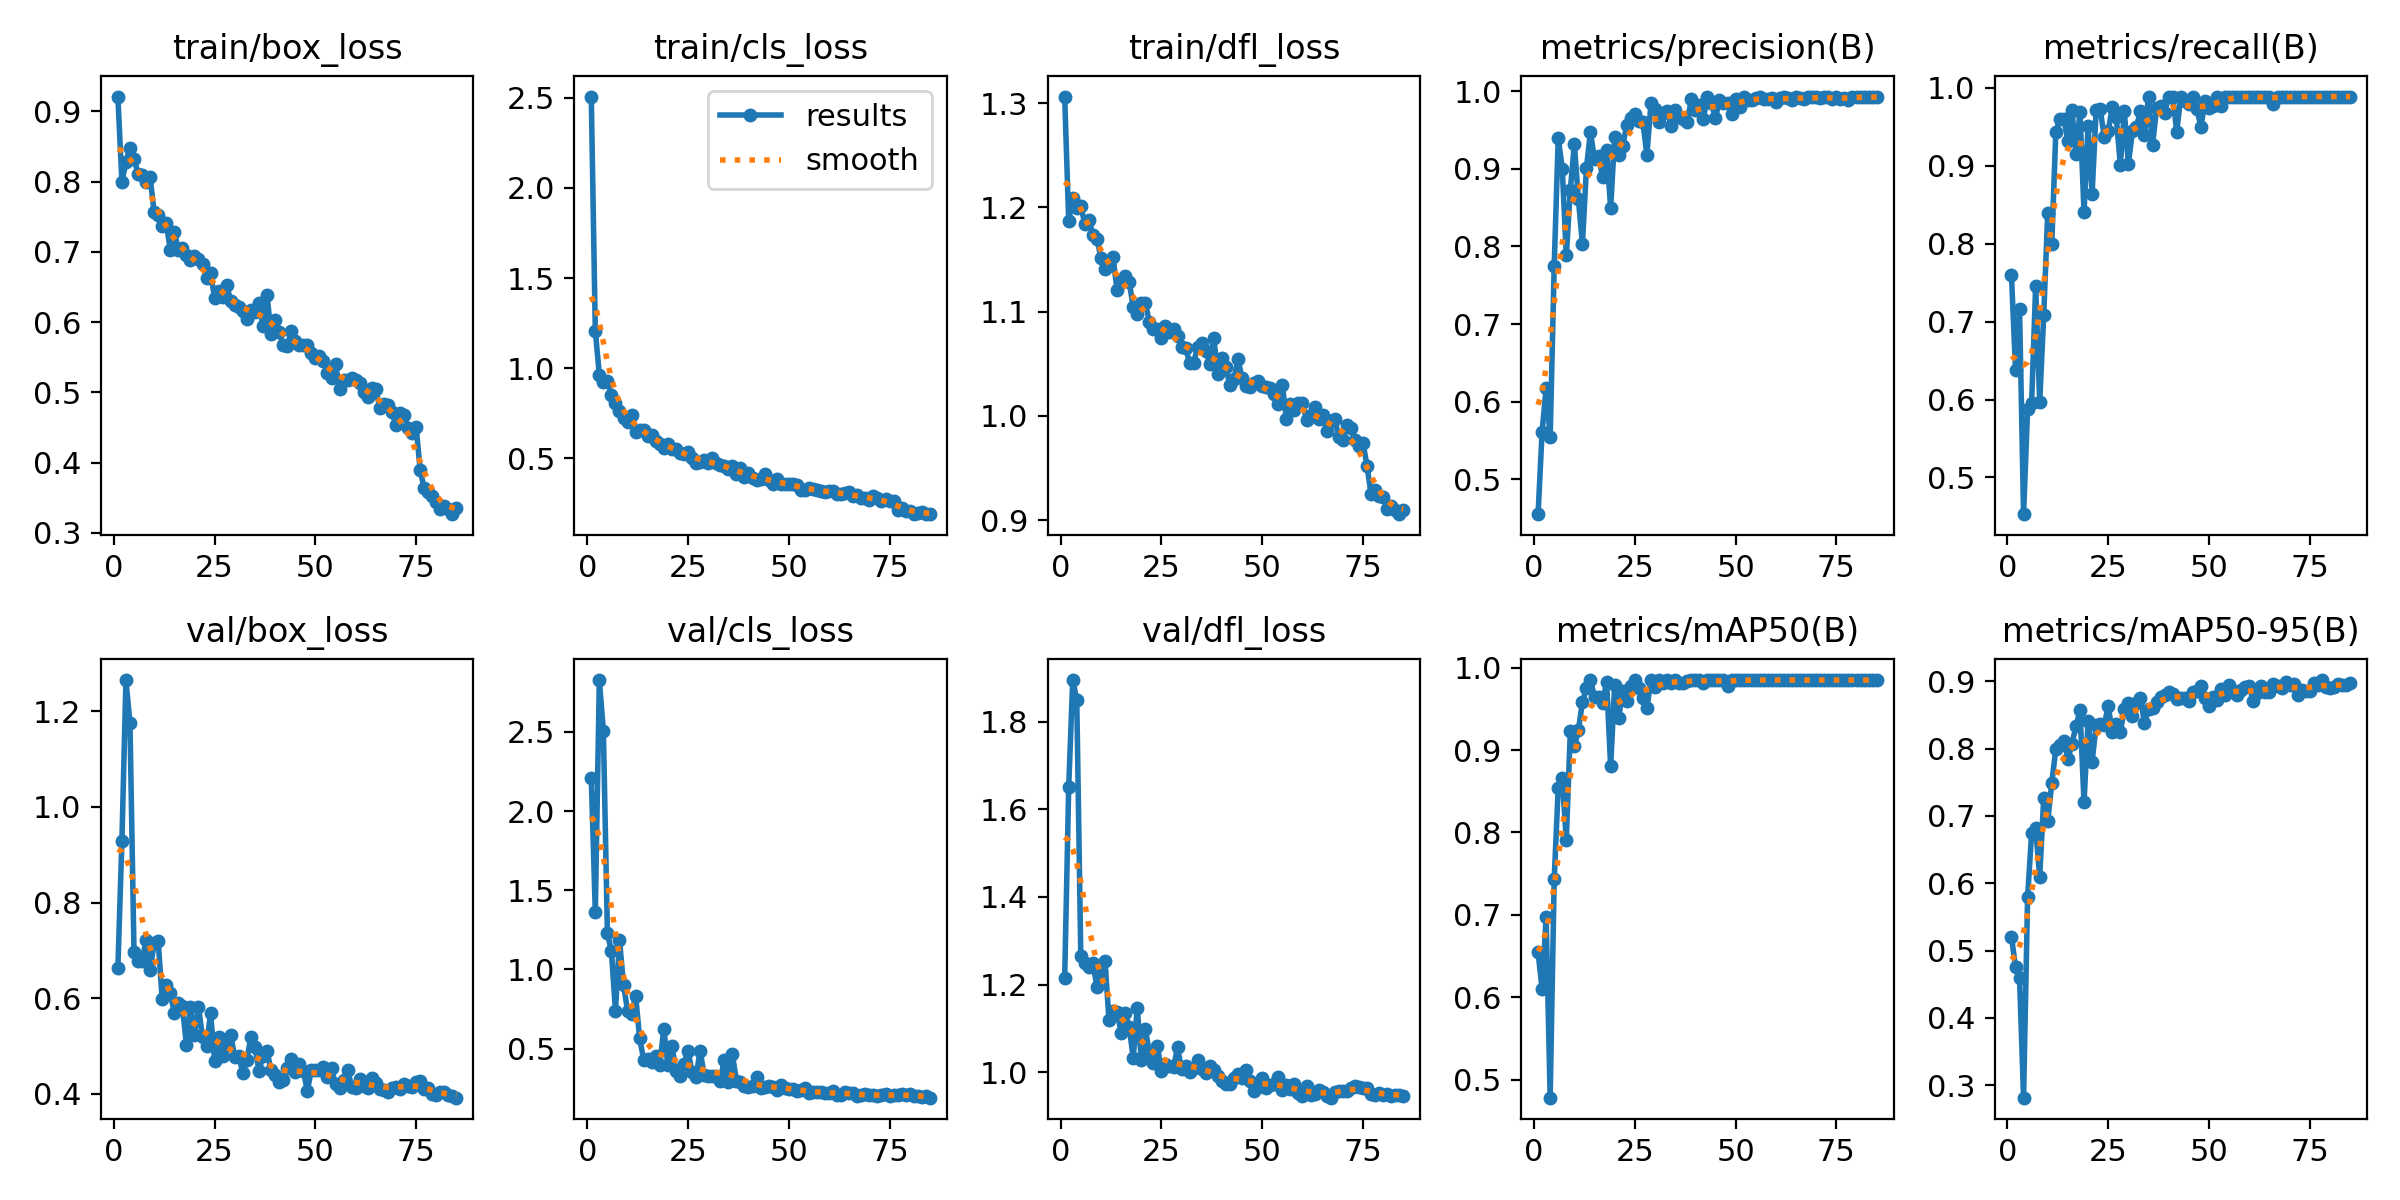

Métricas finais:
epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2

85,5227.12,0.33486,0.19329,0.90997,0.99271,0.98901,0.985,0.89691,0.39232,0.18995,0.94589,1.96772e-05,1.96772e-05,1.96772e-05



In [ ]:
from IPython.display import Image, display
import os

# Caminho correto
caminho = "/content/runs/liderancas_v1"

# Mostra as curvas de treinamento
display(Image(f"{caminho}/results.png"))

# Métricas finais
print("Métricas finais:")
with open(f"{caminho}/results.csv") as f:
    linhas = f.readlines()
    print(linhas[0])   # cabeçalho
    print(linhas[-1])  # última época

## **Baixar o modelo**

In [ ]:
from google.colab import files
import shutil

shutil.copy("/content/runs/liderancas_v1/weights/best.pt", "/content/best.pt")
files.download("/content/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>